In [4]:
import pandas as pd
df = pd.read_csv(
    "datasets/dataset_final.csv",
    engine="python",
    on_bad_lines="skip",
)
df.head()

,count,osm_id,lat,lon,pois_500m,same_category_500m,same_subcategory_500m,unique_subcategory_500m,services_500m,transport_500m,...,transport_type_highway,transport_type_public_transport,transport_type_railway,transport_subtype_bus_station,transport_subtype_bus_stop,transport_subtype_platform,transport_subtype_station,transport_subtype_stop_position,transport_subtype_taxi,transport_subtype_train_station_entrance
0,268.367796,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
1,52.440458,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
2,40.015808,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
3,15.689651,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0
4,13.597078,0.269408,-0.251644,-0.169044,-0.064919,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,...,0,1,0,0,0,1,0,0,0,0


In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'pois_500m')

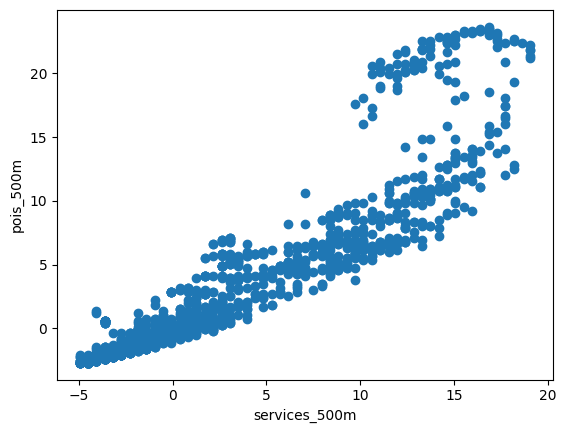

In [6]:
plt.scatter(df["services_500m"], df["pois_500m"])
plt.xlabel("services_500m")
plt.ylabel("pois_500m")

Text(0, 0.5, 'pois_500m')

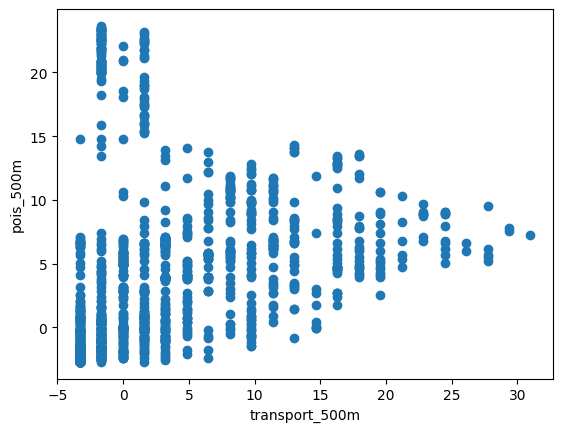

In [7]:
plt.scatter(df["transport_500m"], df["pois_500m"])
plt.xlabel("transport_500m")
plt.ylabel("pois_500m")

In [8]:
import pandas as pd
if "df" not in globals():
    df = pd.read_csv(
        "datasets/dataset_final.csv",
        engine="python",
        on_bad_lines="skip",
    )
target_col = "pois_500m"
X = df.drop(columns=[target_col])
y = df[target_col]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3
)

In [10]:
X_train.shape, X_test.shape

((54019, 242), (23152, 242))

In [11]:
y_train.shape, y_test.shape

((54019,), (23152,))

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model.predict(X_test)
y_pred[:5]

array([-0.06687733, -0.06480669, -0.06517172, -0.0637606 , -0.06484039])

In [14]:
model.score(X_test, y_test)

0.9730871067234841

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)
X_test.head()

,count,osm_id,lat,lon,same_category_500m,same_subcategory_500m,unique_subcategory_500m,services_500m,transport_500m,roads_500m,...,transport_type_highway,transport_type_public_transport,transport_type_railway,transport_subtype_bus_station,transport_subtype_bus_stop,transport_subtype_platform,transport_subtype_station,transport_subtype_stop_position,transport_subtype_taxi,transport_subtype_train_station_entrance
44412,-0.004644,0.626052,1.782917,-0.892442,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,0.013882,...,0,1,0,0,0,1,0,0,0,0
74794,-0.004644,0.690323,-1.521368,0.028010,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,0.013882,...,0,1,0,0,0,1,0,0,0,0
43318,-0.004644,0.622341,1.866574,0.335865,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,0.013882,...,0,1,0,0,0,1,0,0,0,0
8534,-0.004644,-2.457518,-0.106253,-0.893067,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,0.013882,...,0,1,0,0,0,1,0,0,0,0
25966,-0.004644,0.031342,-0.322304,-1.300271,-0.064118,-0.04741,-0.061557,-0.058491,-0.046024,0.013882,...,0,1,0,0,0,1,0,0,0,0
